In [1]:
from torchvision import datasets
import torch
data_folder = '^/data/FMNIST'
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)  # baixa (se ainda não tiver) e carrega o dataset de treino
tr_images = fmnist.data
tr_targets = fmnist.targets

In [2]:
val_fmnist = datasets.FashionMNIST(data_folder, download=True, train=False)  # baixa (se ainda não tiver) e carrega o dataset de treino
val_images = val_fmnist.data
val_targets = val_fmnist.targets

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from torch.optim import SGD, Adam
device = 'cuda' if torch.cuda.is_available() else 'cpu'

## Model with 2 hidden layers

In [4]:
class FMNISTDataset(Dataset):
  def __init__(self,x,y):
    x = x.float()
    X = x.view(-1, 28*28)/255 # normalizando os dados
    # achata cada imagem 28x28 num vetor de 784 e normaliza pra ficar entre 0 e 1
    self.x, self.y = X, y # Changed x to X here to store the flattened and normalized data

  def __getitem__(self, ix):
    x, y = self.x[ix], self.y[ix]
    return x.to(device), y.to(device)

  # manda pro device só na hora de pegar o item
  def __len__(self):
    return len(self.x)

In [5]:
def get_model():
   model = nn.Sequential(
       nn.Linear(28*28, 1000), # entrada
       nn.ReLU(),
       nn.Linear(1000, 1000), # uma camada oculta a mais que o modelo raso
       nn.ReLU(),
       nn.Linear(1000, 10) # 10 saídas para 10 classes do Fashion-MNIST
   ).to(device)

   loss_fn = nn.CrossEntropyLoss()  # já faz softmax + cross entropy junto, não precisa de ativação softmax na ultima camada
   optimizer = Adam(model.parameters(), lr=1e-3)
   return model, loss_fn, optimizer

In [6]:
def train_batch(x, y, model, opt, loss_fn):
  model.train()
  prediction = model(x)
  batch_loss = loss_fn(prediction, y)
  batch_loss.backward()
  optimizer.step()
  optimizer.zero_grad()
  return batch_loss.item()  # .item() pega o valor escalar puro em python, tira do tensor

def accuracy(x, y, model):
  model.eval() # modo avaliação, desliga dropout/batchnorm em modo treino
  with torch.no_grad(): # não precisa guardar gradiente pra só avaliar, economiza memória e processamento
    prediction = model(x)
  max_values, argmaxes = prediction.max(-1)  # pega o indice da classe com maior score
  is_correct = argmaxes == y
  return is_correct.cpu().numpy().tolist()

In [7]:
# decorator que já faz o with torch.no_grad() pra função inteira, mais limpo
@torch.no_grad()
def val_loss(x, y, model):
  prediction = model(x)
  val_loss= loss_fn(prediction, y)
  return val_loss.item()

In [8]:
def get_data():
  train = FMNISTDataset(tr_images, tr_targets)
  trn_dl = DataLoader(train, batch_size=32, shuffle=True)
  val = FMNISTDataset(val_images, val_targets)
  val_dl = DataLoader(val, batch_size=len(val_images), shuffle=False)  # batch de validação, dataset inteiro de uma vez
  return trn_dl, val_dl

In [9]:
trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()

In [10]:
train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []
for epoch in range(5):
  print(epoch)
  train_epoch_losses, train_epoch_accuracies = [], []
  for ix, batch in enumerate(iter(trn_dl)):  # só treina, acumula a loss de cada batch
    x, y = batch
    batch_loss = train_batch(x, y, model, optimizer, loss_fn)
    train_epoch_losses.append(batch_loss)
  train_epoch_loss = np.array(train_epoch_losses).mean()

  for i, batch in enumerate(iter(trn_dl)):  # passa de novo só pra medir a acurácia no treino, já com pesos atualizados
    x, y = batch
    is_correct = accuracy(x, y, model)
    train_epoch_accuracies.extend(is_correct)
  train_epoch_accuracy = np.mean(train_epoch_accuracies)
  for i, batch in enumerate(iter(trn_dl)):
    x, y = batch
    val_is_correct = accuracy(x, y, model)
    validation_loss = val_loss(x, y, model)
  val_epoch_accuracy = np.mean(val_is_correct)
  train_losses.append(train_epoch_loss)
  train_accuracies.append(train_epoch_accuracy)
  val_losses.append(validation_loss)
  val_accuracies.append(val_epoch_accuracy)

0
1
2
3
4


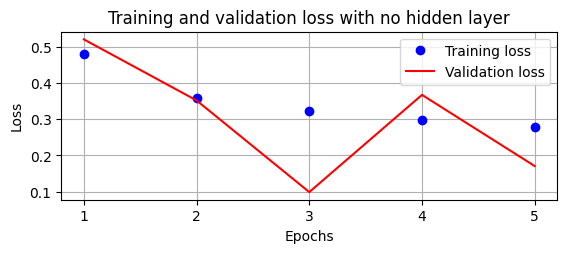

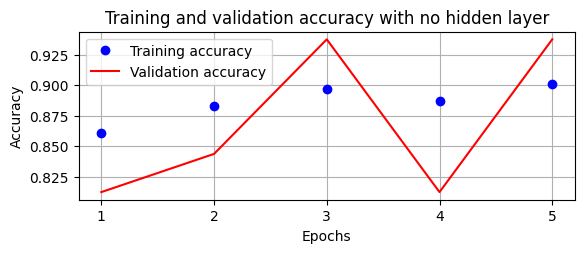

In [12]:
epochs = np.arange(5)+1
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
%matplotlib inline
plt.subplot(211)
plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation loss with no hidden layer')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid('off')
plt.show()
plt.subplot(212)
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation accuracy with no hidden layer')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid('off')
plt.show()